##### **Multi-Model (Cell Nuclei Features) Breast Cancer Diagnosis Prediction**

###### **Meritshot Intenship**

This project aims to **build a machine learning model that predicts whether a breast tumor is malignant (cancerous) or benign (non-cancerous)**. Early detection is important because it improves treatment outcomes. What's makes this good is that ML models can potentially analyze patterns accross mulitple features simultanously, potentially catching patterns humans can miss. The **goal is to develop a reliable prediction system using cell nuclear morphological features and  then image data**. The project workflow is as follows:
1. Problem Statement
2. Dataset Description
3. Data Loading
4. Data Overview
5. Data Cleaning
6. Data Preprocessing
7. Feature Engineering
8. EDA
9. Model Building
10. Model Evaluation
11. Prediction
12. Insights & Conclusion

###### **1. Problem Statement**

Breast cancer is one of the most common cancers in the world, and detecting it early can save or prolong lives. While doctors typically rely on lab results and imaging tests to determine whether a tumor is cancerous, analyzing large numbers of histopathology images manually can be time-consuming and prone to error.

In this project, the goal is simple: **build a machine learning model that can predict whether a tumor is malignant (cancerous) or benign (non-cancerous) using cell nuclear morphological features extracted from digitized biopsy images using computer-based image analysis.**
Later, we will improve the system by **adding image data to simulate how real hospital systems use multiple types of information to support diagnosis.**

**The aim is to explore how data-driven methods can support early diagnosis and assist clinical decision-making.**

###### **2. Dataset Description**

The dataset used in this project is the Breast Cancer Wisconsin (Diagnostic) dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic).

It contains 569 patient samples and 30 numerical features that describe characteristics of cell nuclei taken from breast tumor samples and is a well studied, reliable dataset suitable for classification problems. These features were computed from digitized images of fine needle aspirate (FNA) tests gotten from real medical tests, so the model learns learns the data that actually matters for doctors.

Each record represents one tumor and includes measurements such as:
* Radius ~ Size of the nucleus
* Texture ~ Standard deviation of grayscale values
* Smoothness ~ Local variation in radius length
* Compactness ~ Perimeter² / Area − 1
* Concavity ~ Severity of concave portions of the contour
* Concave points ~ Number of concave portions
* Symmetry ~ Symmetry of the nucleus
* Fractal dimension ~ Border irregularity complexity

Malignant cells typically show:
- Larger nuclei
- Irregular borders
- Higher concavity
- Greater variability

The target variable is binary:
* 0 = Malignant (cancerous)
* 1 = Benign (non-cancerous)

This dataset is widely used for classification tasks and is suitable for building and evaluating diagnostic prediction models.

##### **3. Data Loading**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

# loading dataset
data = load_breast_cancer()

# converting to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# adding target column
df["target"] = data.target

# displaying first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.shape

(569, 31)

##### **4. Data Overview**

In [ ]:
# basic infomation
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
# summary statistics
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
# checking the target distribution
df["target"].value_counts()

,count
target,
1,357
0,212


##### **5. Data Cleaning**

In [ ]:
# checking for duplicates
print(df.duplicated().sum())

0


##### **6. Data Preprocessing**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
# spliting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### **7. Feature Engineering**

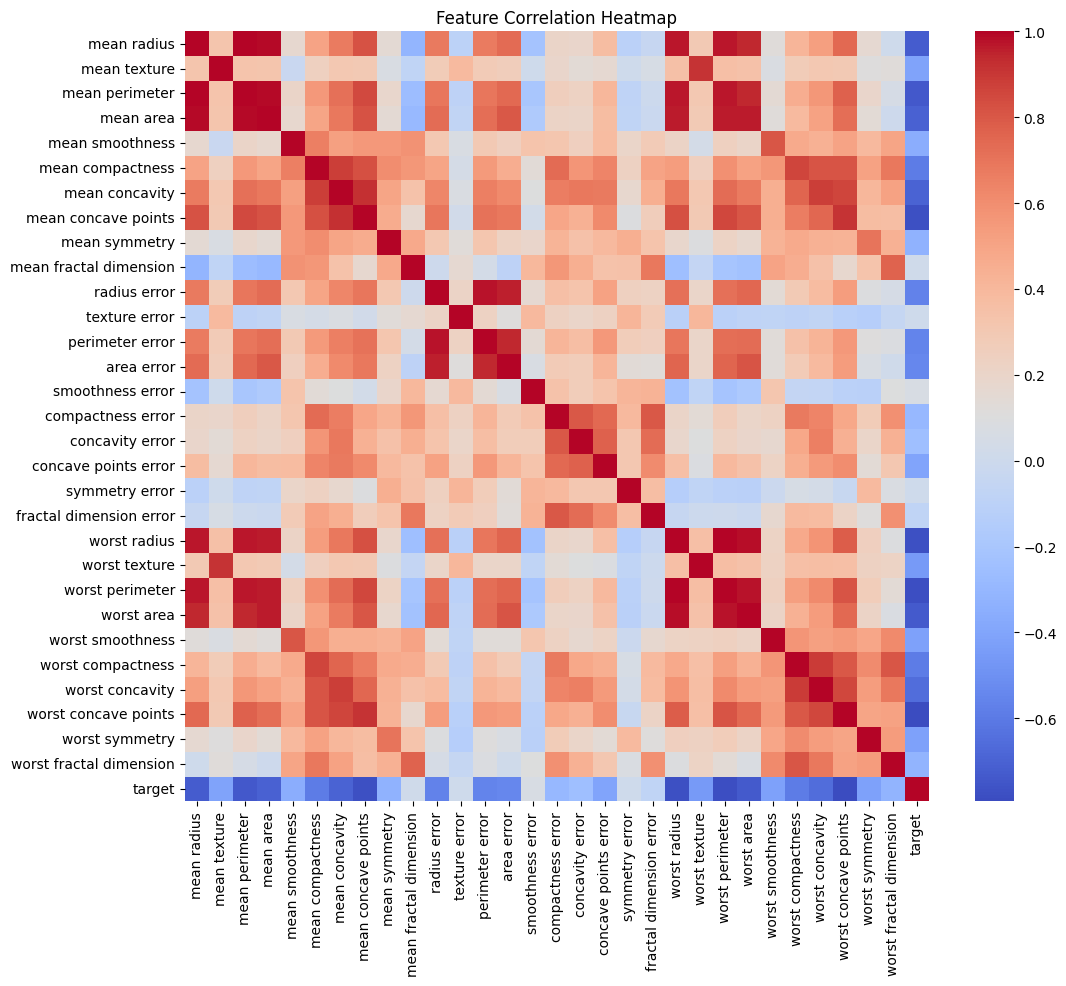

In [ ]:
# checking correlation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

##### **8. Exploratory Data Analysis**

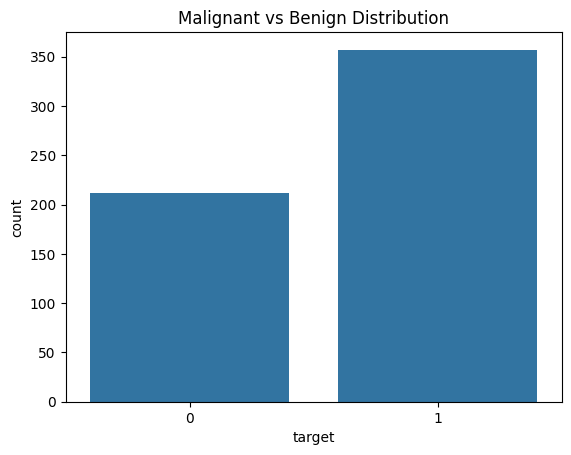

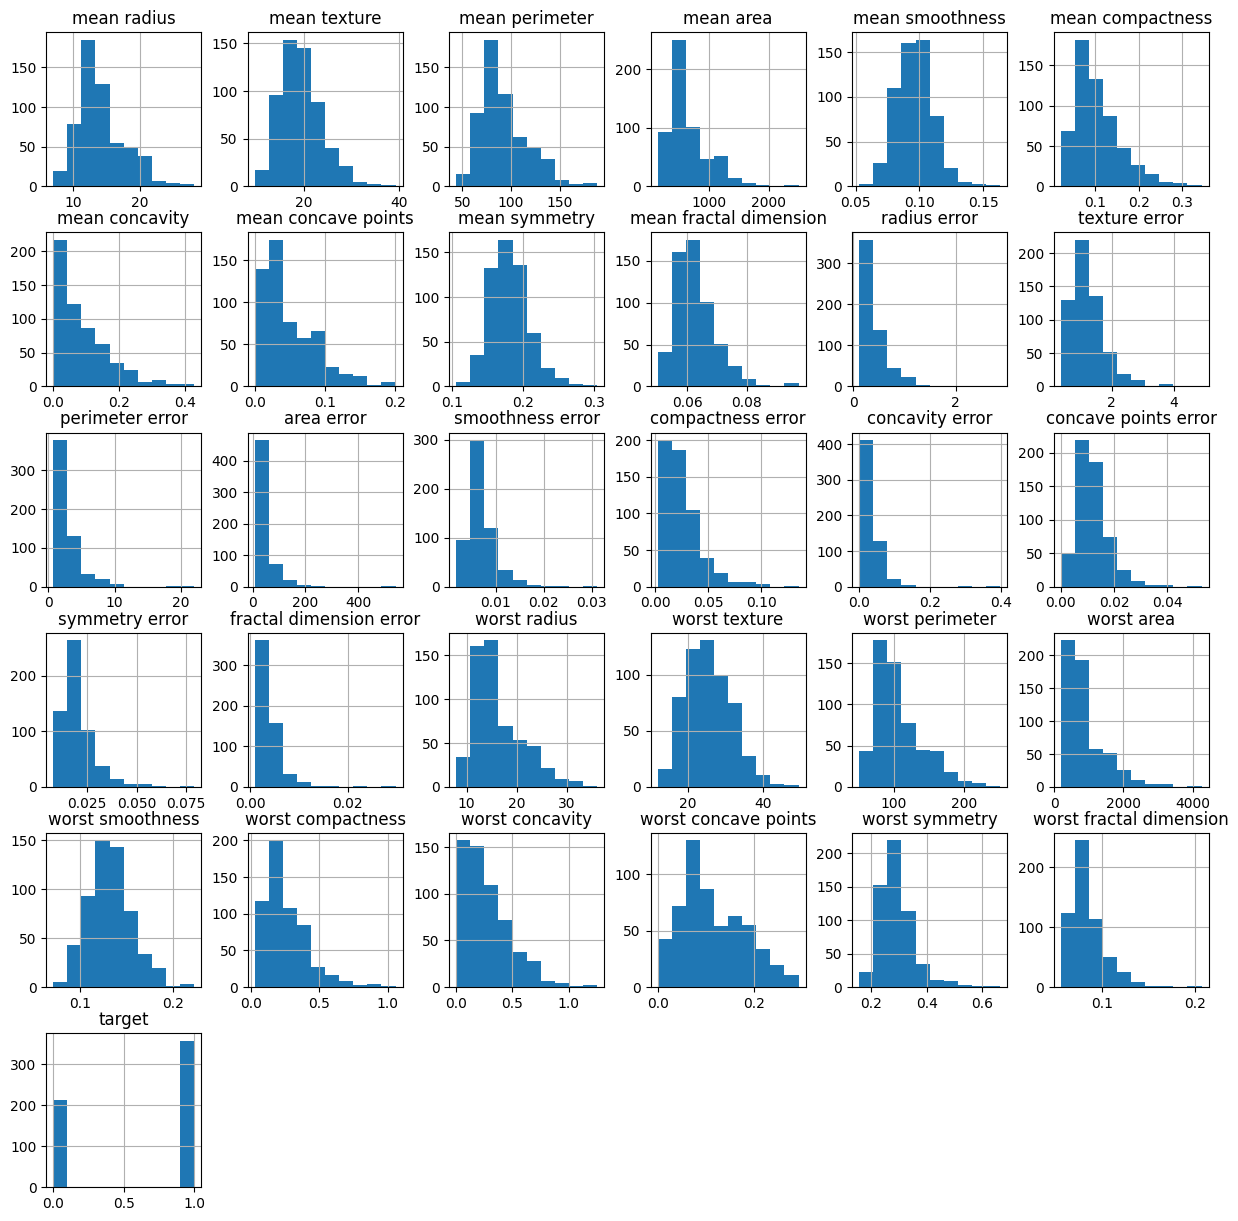

In [ ]:
# target distribution
sns.countplot(x="target", data=df)
plt.title("Malignant vs Benign Distribution")
plt.show()

# feature distributions
df.hist(figsize=(15,15))
plt.show()

##### **9. Model Building**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

##### **10. Model Evaluation**

---Logistic Regression---
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112
Confusion Matrix:
 [[41  1]
 [ 1 71]]
---Random Forest---
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104
Confusion Matrix:
 [[39  3]
 [ 2 70]]
---XGBoost---
Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1 Score: 0.9659863945578231
Confusion Matrix:
 [[38  4]
 [ 1 71]]


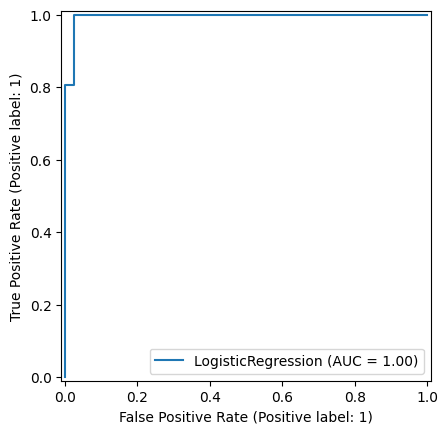

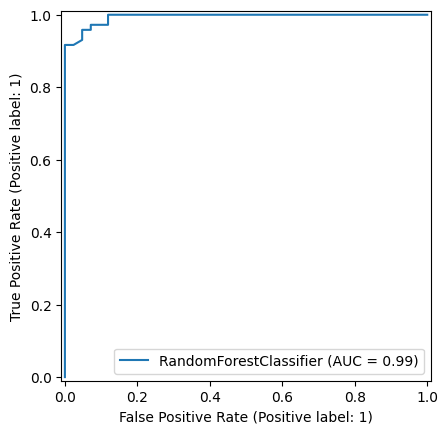

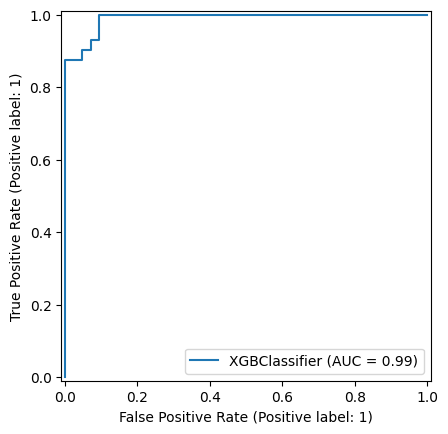

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, RocCurveDisplay

models = {"Logistic Regression": lr, "Random Forest": rf, "XGBoost": xgb}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"---{name}---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # ROC Curve
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)

###### Logistic Regression achieved the highest accuracy (98.24%) with minimal false negatives, making it the most reliable model for early breast cancer detection in this dataset. Despite the availability of more complex models such as Random Forest and XGBoost, the simpler linear model performed best, demonstrating that model complexity does not always guarantee better performance.

##### **11. Prediction**

In [ ]:
sample = X_test_scaled[0].reshape(1, -1)
pred = lr.predict(sample)
print("Prediction:", "Malignant" if pred[0]==0 else "Benign")

Prediction: Malignant


In [ ]:
# saving the model
import joblib

# saving
joblib.dump(lr, "logistic_model.pkl")
joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(xgb, "xgb_model.pkl")

# load later
lr_loaded = joblib.load("logistic_model.pkl")

##### **12. Insights and Conclusion**

**Insights**

1. **The dataset is clean and well structured:**
There was no missing values or duplicates, which allows the models to train without additional imputation or cleaning steps.

2. **The classes are reasonably balanced:**
The dataset contains both malignant and benign cases in proportions that allow meaningful model evaluation without severe class imbalance issues.

3. **Logistic Regression outperformed more complex models:**
Logistic Regression achieved the highest accuracy (98.24%) and demonstrated excellent precision and recall. This suggests that the dataset is close to linearly separable and does not require highly complex nonlinear models.

4. **False negatives were minimal across models:**
In medical diagnosis, false negatives are critical because missing a malignant tumor can delay treatment. Logistic Regression and XGBoost both maintained very high recall, reducing this risk.

5. **Model simplicity can enhance interpretability:**
Logistic Regression provides interpretable coefficients, making it easier to understand which features contribute most to classification decisions. In clinical settings, interpretability increases trust and adoption.

**Conclusion**

This project successfully developed and evaluated multiple machine learning models to predict breast tumor malignancy using structured clinical features. Among the tested models, Logistic Regression achieved the highest overall performance, demonstrating that simpler linear models can outperform more complex ensemble methods when the data structure supports linear separation.

The results show that machine learning can effectively assist in early breast cancer detection by identifying patterns across multiple clinical measurements. However, while the performance is strong on this dataset, further validation on larger and more diverse real-world data is necessary before clinical deployment.

This phase of the project establishes a solid structured data diagnostic model. The next step is to enhance the system by incorporating image-based data, moving toward a more realistic multi-modal diagnostic framework similar to modern hospital decision support systems.